# Static dynII on delay-embedded neural signals

Prototype notebook: load neural rasters at 200 Hz, create delay embeddings using `TimeSeries.delay_embeddings`, run static-dynamic Information Imbalance on the delay-embedded neural signal, and plot the results. Nothing is saved to disk.

In [ ]:
import os, sys, yaml
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[1]

with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import load_img_natraster, map_image_order_from_ann_to_monkey
from II_analyses.static_dyn import init_static_dynII
from useful_stuff.general_utils.utils import TimeSeries, print_wise
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

## Parameters

`new_fs=200` keeps the temporal resolution high. With `delay_lags=(-2, 0)`, each embedded vector contains `[t-10 ms, t-5 ms, t]` at 200 Hz.

In [37]:
cfg = SimpleNamespace(
    monkey_name="three0",
    date="250313",
    brain_area="AIT",
    folder_name="talia_20each_tizi",
    signal_RDM_metric="cosine_cnt",
    model_RDM_metric="cosine_cnt",
    model_name="vit_l_16",
    img_size=384,
    pooling="mean",
    new_fs=500,
    pkg="timm",
    k=10,
    delay_lags=(-20, 0),
    pad_mode=None,
    use_subsamples=True,
    subsamples_size=200,
    n_iterations=10,
    random_seed=0,
    layers_to_plot=None,  # None = use the first n_layers_to_plot relevant layers
    n_layers_to_plot=24,
)

print_wise(cfg)

13:10:33 - namespace(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', signal_RDM_metric='cosine_cnt', model_RDM_metric='cosine_cnt', model_name='vit_l_16', img_size=384, pooling='mean', new_fs=500, pkg='timm', k=10, delay_lags=(-20, 0), pad_mode=None, use_subsamples=True, subsamples_size=200, n_iterations=10, random_seed=0, layers_to_plot=None, n_layers_to_plot=24)


## Delay-embed raster

`TimeSeries.delay_embeddings` is implemented for 2D arrays, so this helper applies it separately to each image/trial slice `(neurons, time)` and stacks back to `(embedded_features, embedded_time, images)`.

In [38]:
def delay_embed_raster(raster: TimeSeries, lags: tuple[int, int], pad_mode: str | None = None) -> TimeSeries:
    X = raster.get_array()
    if X.ndim != 3:
        raise ValueError(f"Expected raster shape (neurons, time, images/trials), got {X.shape}")

    embedded_trials = []
    for image_idx in range(X.shape[2]):
        image_ts = TimeSeries(X[:, :, image_idx], raster.get_fs())
        embedded_trials.append(image_ts.delay_embeddings(lags, pad_mode=pad_mode).get_array())

    embedded = np.stack(embedded_trials, axis=2)
    return TimeSeries(embedded, raster.get_fs())


def delay_embedding_label(lags: tuple[int, int], pad_mode: str | None) -> str:
    pad = "valid" if pad_mode is None else pad_mode
    return f"delayemb_lags{lags[0]}to{lags[1]}_{pad}"

## Load data and create delay embeddings

In [39]:
area_rasters = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

print_wise(f"raw raster shape: {area_rasters.get_array().shape}, fs={area_rasters.get_fs()} Hz")

area_rasters_delay = delay_embed_raster(
    area_rasters,
    lags=cfg.delay_lags,
    pad_mode=cfg.pad_mode,
)

print_wise(f"delay-embedded raster shape: {area_rasters_delay.get_array().shape}, fs={area_rasters_delay.get_fs()} Hz")

13:10:35 - raw raster shape: (25, 150, 776), fs=500 Hz
13:10:35 - delay-embedded raster shape: (525, 130, 776), fs=500 Hz


## Match model image order to neural image order

In [40]:
dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"),
    allow_empty=True,
)

idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)

print_wise(f"dataset images: {len(dataset)}")
print_wise(f"image-order index length: {len(idx_ord)}")

13:10:35 - dataset images: 776
13:10:35 - image-order index length: 776


## Initialize static dynII from delay-embedded neural signal

`init_static_dynII` computes the signal RDM time series and the signal distance-rank time series once. Each model layer is then compared to that fixed delay-embedded neural representation.

If `cfg.use_subsamples=True`, this full initialization is skipped because signal RDMs/ranks must be recomputed separately inside each image subset.

In [41]:
if cfg.use_subsamples:
    dyn_ii_obj = None
    print_wise("subsample mode enabled: signal RDM/ranks will be recomputed within each subset")
else:
    dyn_ii_obj = init_static_dynII(
        area_rasters_delay,
        cfg.signal_RDM_metric,
        cfg.model_RDM_metric,
        cfg.k,
    )

    signal_rdms = dyn_ii_obj.get_RDM_timeseries("signal")
    print_wise(f"signal RDM time series length: {len(signal_rdms)}, fs={signal_rdms.get_fs()} Hz")

13:10:35 - subsample mode enabled: signal RDM/ranks will be recomputed within each subset


## Select layers

Run this cell and inspect `task_list` if you want to set `cfg.layers_to_plot` manually.

In [42]:
task_list = get_relevant_output_layers(cfg.model_name, cfg.pkg)
layers_to_plot = cfg.layers_to_plot or task_list[:cfg.n_layers_to_plot]
delay_label = delay_embedding_label(cfg.delay_lags, cfg.pad_mode)

print_wise(f"available layers: {len(task_list)}")
print_wise(f"selected layers: {layers_to_plot}")
task_list

13:10:35 - available layers: 24
13:10:35 - selected layers: ['blocks.0.mlp.fc2', 'blocks.1.mlp.fc2', 'blocks.2.mlp.fc2', 'blocks.3.mlp.fc2', 'blocks.4.mlp.fc2', 'blocks.5.mlp.fc2', 'blocks.6.mlp.fc2', 'blocks.7.mlp.fc2', 'blocks.8.mlp.fc2', 'blocks.9.mlp.fc2', 'blocks.10.mlp.fc2', 'blocks.11.mlp.fc2', 'blocks.12.mlp.fc2', 'blocks.13.mlp.fc2', 'blocks.14.mlp.fc2', 'blocks.15.mlp.fc2', 'blocks.16.mlp.fc2', 'blocks.17.mlp.fc2', 'blocks.18.mlp.fc2', 'blocks.19.mlp.fc2', 'blocks.20.mlp.fc2', 'blocks.21.mlp.fc2', 'blocks.22.mlp.fc2', 'blocks.23.mlp.fc2']


['blocks.0.mlp.fc2',
 'blocks.1.mlp.fc2',
 'blocks.2.mlp.fc2',
 'blocks.3.mlp.fc2',
 'blocks.4.mlp.fc2',
 'blocks.5.mlp.fc2',
 'blocks.6.mlp.fc2',
 'blocks.7.mlp.fc2',
 'blocks.8.mlp.fc2',
 'blocks.9.mlp.fc2',
 'blocks.10.mlp.fc2',
 'blocks.11.mlp.fc2',
 'blocks.12.mlp.fc2',
 'blocks.13.mlp.fc2',
 'blocks.14.mlp.fc2',
 'blocks.15.mlp.fc2',
 'blocks.16.mlp.fc2',
 'blocks.17.mlp.fc2',
 'blocks.18.mlp.fc2',
 'blocks.19.mlp.fc2',
 'blocks.20.mlp.fc2',
 'blocks.21.mlp.fc2',
 'blocks.22.mlp.fc2',
 'blocks.23.mlp.fc2']

## Compute static dynII and plot

Results stay in memory as `dynii_by_layer`; nothing is saved. `A2B` means signal-neighborhoods condition model-ranks; `B2A` means model-neighborhoods condition signal-ranks.

When `cfg.use_subsamples=True`, each layer stores the iteration mean and std for each direction and plots mean ± std.

Task was destroyed but it is pending!
task: <Task pending name='Task-272' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/tizianocausin/Desktop/metrics_II/.venv/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-273' coro=<Kernel.shell_main() running at /Users/tizianocausin/Desktop/metrics_II/.venv/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/tizianocausin/Desktop/metrics_II/.venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/homebrew/Cellar/python@3.14/3.14.0_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/collections/__init__.py:453: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  @classmethod
Task was destroyed but it is pending!
task: <Task pending name='Task-273' coro=<Kernel.shell_main() running at /Users/tizianocausin/Desktop/metrics_II/.venv/lib/python3.14/site-packages/ip

15:20:57 - blocks.0.mlp.fc2: completed subsample 1/10
15:20:57 - blocks.0.mlp.fc2: completed subsample 2/10
15:20:58 - blocks.0.mlp.fc2: completed subsample 3/10
15:20:58 - blocks.0.mlp.fc2: completed subsample 4/10
15:20:58 - blocks.0.mlp.fc2: completed subsample 5/10
15:20:58 - blocks.0.mlp.fc2: completed subsample 6/10
15:20:59 - blocks.0.mlp.fc2: completed subsample 7/10
15:20:59 - blocks.0.mlp.fc2: completed subsample 8/10
15:20:59 - blocks.0.mlp.fc2: completed subsample 9/10
15:21:00 - blocks.0.mlp.fc2: completed subsample 10/10
15:21:00 - computed subsampled static dynII for blocks.0.mlp.fc2
15:21:00 - blocks.1.mlp.fc2: completed subsample 1/10
15:21:00 - blocks.1.mlp.fc2: completed subsample 2/10
15:21:01 - blocks.1.mlp.fc2: completed subsample 3/10
15:21:01 - blocks.1.mlp.fc2: completed subsample 4/10
15:21:01 - blocks.1.mlp.fc2: completed subsample 5/10
15:21:02 - blocks.1.mlp.fc2: completed subsample 6/10
15:21:02 - blocks.1.mlp.fc2: completed subsample 7/10
15:21:02 - block

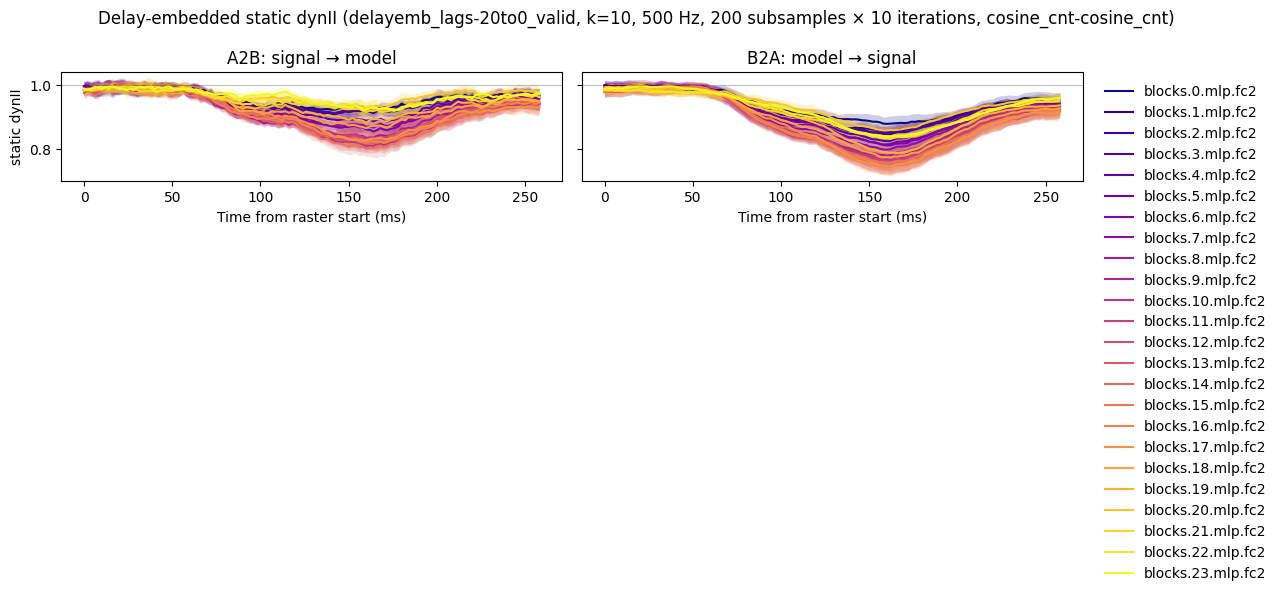

In [44]:
def compute_static_dynII_delay_embedded(layer_name: str):
    feats_filename = Path(paths["data_path"]) / "models" / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_"
        f"{layer_name}_features_{cfg.pooling}pool.npz"
    )
    features = np.load(feats_filename)["arr_0"][:, idx_ord]

    if not cfg.use_subsamples:
        dyn_ii_obj.compute_RDM(features, "model")
        dyn_ii_obj.compute_distance_ranks("model")
        dynii_A2B, dynii_B2A = dyn_ii_obj.compute_both_static_dynII()
        print_wise(f"computed static dynII for {layer_name}")
        return {
            "A2B_mean": dynii_A2B.get_array(),
            "B2A_mean": dynii_B2A.get_array(),
            "A2B_std": None,
            "B2A_std": None,
        }

    raster_array = area_rasters_delay.get_array()
    n_trials = raster_array.shape[2]
    if cfg.subsamples_size > n_trials:
        raise ValueError(f"subsamples_size={cfg.subsamples_size} exceeds available trials/images ({n_trials})")
    if cfg.n_iterations < 1:
        raise ValueError("n_iterations must be >= 1")

    rng = np.random.default_rng(cfg.random_seed)
    A2B_iterations = []
    B2A_iterations = []

    for iteration in range(cfg.n_iterations):
        subset = rng.choice(n_trials, size=cfg.subsamples_size, replace=False)
        subset_raster = TimeSeries(raster_array[:, :, subset], area_rasters_delay.get_fs())
        subset_features = features[:, subset]

        subset_dyn_ii_obj = init_static_dynII(
            subset_raster,
            cfg.signal_RDM_metric,
            cfg.model_RDM_metric,
            cfg.k,
        )
        subset_dyn_ii_obj.compute_RDM(subset_features, "model")
        subset_dyn_ii_obj.compute_distance_ranks("model")
        dynii_A2B, dynii_B2A = subset_dyn_ii_obj.compute_both_static_dynII()
        A2B_iterations.append(dynii_A2B.get_array())
        B2A_iterations.append(dynii_B2A.get_array())
        print_wise(f"{layer_name}: completed subsample {iteration + 1}/{cfg.n_iterations}")

    A2B_iterations = np.stack(A2B_iterations, axis=0)
    B2A_iterations = np.stack(B2A_iterations, axis=0)
    print_wise(f"computed subsampled static dynII for {layer_name}")
    return {
        "A2B_mean": A2B_iterations.mean(axis=0),
        "B2A_mean": B2A_iterations.mean(axis=0),
        "A2B_std": A2B_iterations.std(axis=0),
        "B2A_std": B2A_iterations.std(axis=0),
        "A2B_iterations": A2B_iterations,
        "B2A_iterations": B2A_iterations,
    }


dynii_by_layer = {
    layer_name: compute_static_dynII_delay_embedded(layer_name)
    for layer_name in layers_to_plot
}

